In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Capture Estimation

Use BayNorm capture estimation method: slight variation of standard total count normalization as includes filtering of some "low quality" genes

In [2]:
def mad(x):
    """
    Exact replication of R's mad():
    mad(x, constant = 1.4826, center = median(x))
    """
    x = np.asarray(x)
    x = x[~np.isnan(x)]  # match R's na.rm = TRUE behavior
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))

In [3]:
def Check_input(Data):
    """
    Minimal placeholder for the R Check_input().
    Ensures Data is a numeric pandas DataFrame.
    """
    if not isinstance(Data, pd.DataFrame):
        Data = pd.DataFrame(Data)
    return Data.astype(float)

In [4]:
def BetaFun(Data, MeanBETA):
    # Set matrix as object for input data
    Data = Check_input(Data)

    # Column sums
    xx = Data.sum(axis=0)

    # Normcount <- t(t(Data)/xx) * mean(xx)
    Normcount = Data.div(xx, axis=1) * xx.mean()

    # Row means
    means = Normcount.mean(axis=1)
    lmeans = np.log(means)

    # Row-wise median and MAD of log(Normcount + 1)
    log_norm = np.log(Normcount + 1)

    med = log_norm.apply(np.median, axis=1)
    mad_vals = log_norm.apply(mad, axis=1)

    bound = med + 3 * mad_vals

    # Row-wise max
    maxlogGene = log_norm.max(axis=1)

    # ind <- which(maxlogGene < bound)
    ind = maxlogGene[maxlogGene < bound].index

    # dropout rate per gene
    dropout = (Data == 0).sum(axis=1) / Data.shape[1]

    # Select_ind <- intersect(ind, which(dropout < 0.35))
    Select_ind = ind.intersection(dropout[dropout < 0.35].index)

    Selected_genes = Select_ind.to_numpy()

    # temppp <- colSums(Data[Select_ind, ])
    temppp = Data.loc[Select_ind].sum(axis=0)

    # BETA <- temppp/mean(temppp) * MeanBETA
    BETA = temppp / temppp.mean() * MeanBETA

    # Truncate BETA values
    if (BETA >= 1).any():
        BETA[BETA >= 1] = BETA[BETA < 1].max()

    if (BETA <= 0).any():
        BETA[BETA <= 0] = BETA[BETA > 0].min()

    # names(BETA) <- colnames(Data)
    BETA.index = Data.columns

    return {
        "BETA": BETA,
        "Selected_genes": Selected_genes
    }

## Data Loading

In [5]:
data_d0 = pd.read_csv("../Data/GSE151334_d0_counts_common.csv", index_col=0)
data_d4 = pd.read_csv("../Data/GSE151334_d4_counts_common.csv", index_col=0)
data_d8 = pd.read_csv("../Data/GSE151334_d8_counts_common.csv", index_col=0)
data_d12 = pd.read_csv("../Data/GSE151334_d12_counts_common.csv", index_col=0)

## Estimation

In [6]:
# run
beta_d0_dict = BetaFun(data_d0, 0.1)
beta_d4_dict = BetaFun(data_d4, 0.1)
beta_d8_dict = BetaFun(data_d8, 0.1)
beta_d12_dict = BetaFun(data_d12, 0.1)

# extract capture
beta_d0 = beta_d0_dict['BETA'].to_numpy()
beta_d4 = beta_d4_dict['BETA'].to_numpy()
beta_d8 = beta_d8_dict['BETA'].to_numpy()
beta_d12 = beta_d12_dict['BETA'].to_numpy()

## Save

In [40]:
np.savetxt("beta_d0.txt", beta_d0)
np.savetxt("beta_d4.txt", beta_d4)
np.savetxt("beta_d8.txt", beta_d8)
np.savetxt("beta_d12.txt", beta_d12)

## Compare to Basic method

Total count normalization with no gene selection

In [19]:
def estimate_capture_basic(df, beta_mean=0.1):

    total_cell_counts = df.sum(axis='rows')
    total_counts_mean = total_cell_counts.mean()
    beta_basic = np.array(total_cell_counts / total_counts_mean) * beta_mean
    beta_basic[beta_basic > 1] = 1
    beta_basic[beta_basic < 0] = 0
    
    return beta_basic

In [20]:
beta_basic_d0 = estimate_capture_basic(data_d0)
beta_basic_d4 = estimate_capture_basic(data_d4)
beta_basic_d8 = estimate_capture_basic(data_d8)
beta_basic_d12 = estimate_capture_basic(data_d12)

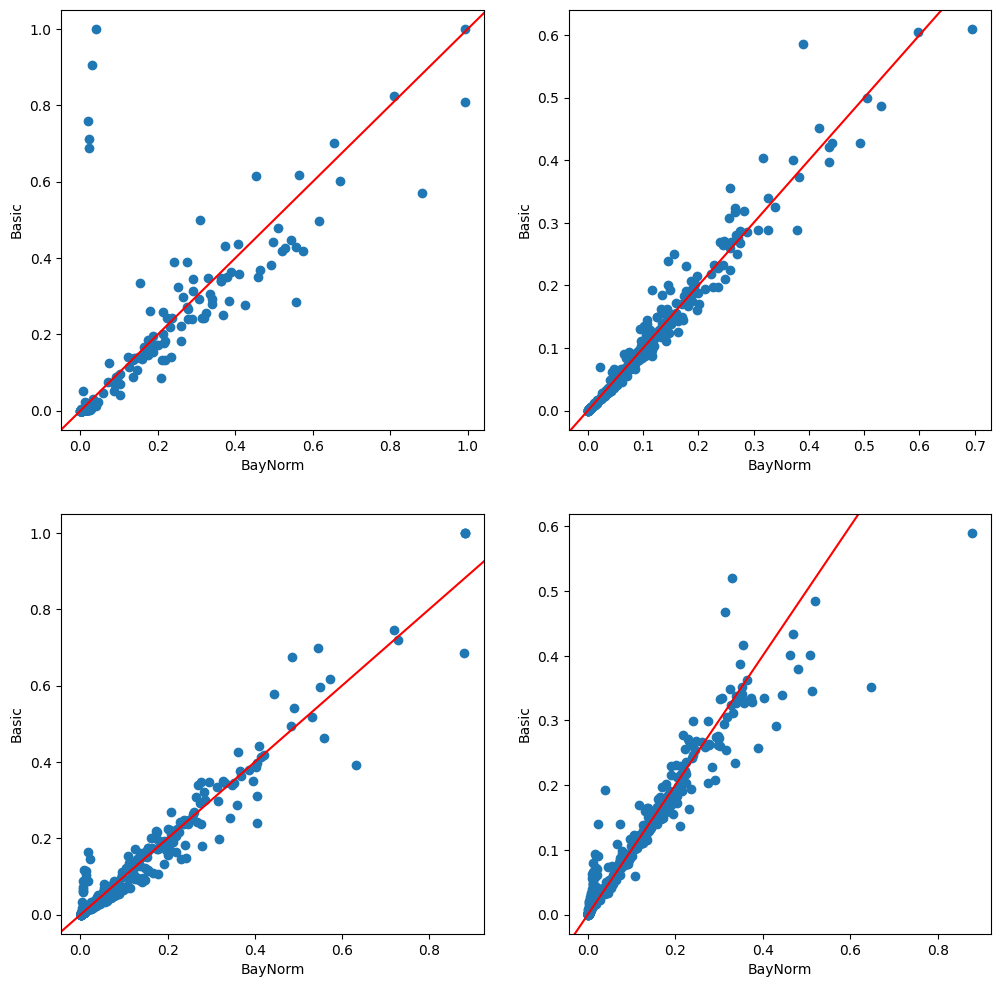

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs[0, 0].scatter(beta_d0, beta_basic_d0)
axs[0, 0].axline([0, 0], [0.1, 0.1], color="red")
axs[0, 0].set_xlabel("BayNorm")
axs[0, 0].set_ylabel("Basic")
axs[0, 1].scatter(beta_d4, beta_basic_d4)
axs[0, 1].axline([0, 0], [0.1, 0.1], color="red")
axs[0, 1].set_xlabel("BayNorm")
axs[0, 1].set_ylabel("Basic")
axs[1, 0].scatter(beta_d8, beta_basic_d8)
axs[1, 0].axline([0, 0], [0.1, 0.1], color="red")
axs[1, 0].set_xlabel("BayNorm")
axs[1, 0].set_ylabel("Basic")
axs[1, 1].scatter(beta_d12, beta_basic_d12)
axs[1, 1].axline([0, 0], [0.1, 0.1], color="red")
axs[1, 1].set_xlabel("BayNorm")
axs[1, 1].set_ylabel("Basic")
plt.show()

Basic method produces some very high capture values

## Compare to concatenation

Combine all days to one dataset and use to estimate per cell capture

In [35]:
# concatenate
data_d = pd.concat([data_d0, data_d4, data_d8, data_d12], axis=1)

# estimate capture
beta_d_dict = BetaFun(data_d, 0.1)

# extract capture
beta_d = beta_d_dict['BETA'].to_numpy()

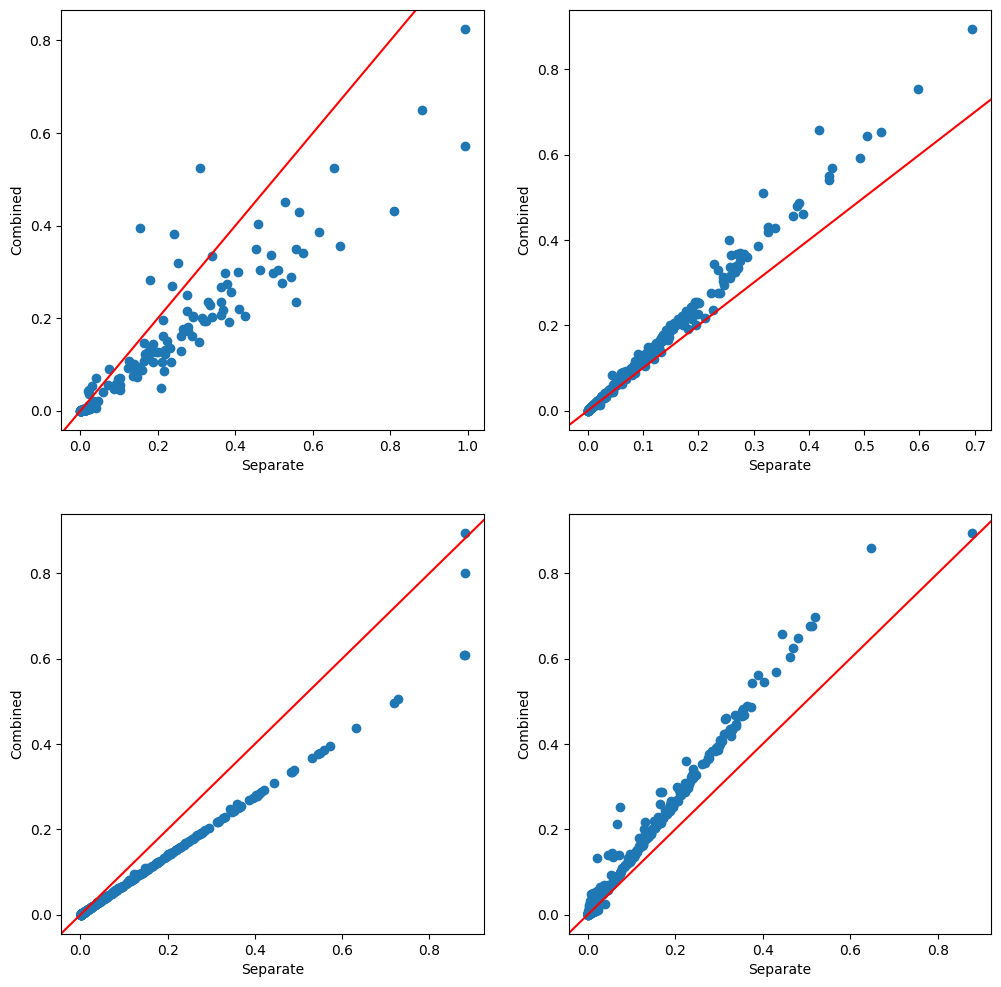

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs[0, 0].scatter(beta_d0, beta_d[:322])
axs[0, 0].axline([0, 0], [0.1, 0.1], color="red")
axs[0, 0].set_xlabel("Separate")
axs[0, 0].set_ylabel("Combined")
axs[0, 1].scatter(beta_d4, beta_d[322:659])
axs[0, 1].axline([0, 0], [0.1, 0.1], color="red")
axs[0, 1].set_xlabel("Separate")
axs[0, 1].set_ylabel("Combined")
axs[1, 0].scatter(beta_d8, beta_d[659:1069])
axs[1, 0].axline([0, 0], [0.1, 0.1], color="red")
axs[1, 0].set_xlabel("Separate")
axs[1, 0].set_ylabel("Combined")
axs[1, 1].scatter(beta_d12, beta_d[1069:1465])
axs[1, 1].axline([0, 0], [0.1, 0.1], color="red")
axs[1, 1].set_xlabel("Separate")
axs[1, 1].set_ylabel("Combined")
plt.show()

In [37]:
# basic method
beta_basic_d = estimate_capture_basic(data_d)

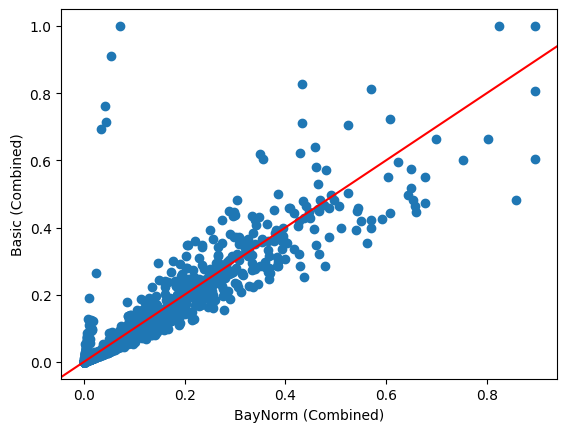

In [39]:
plt.scatter(beta_d, beta_basic_d)
plt.axline([0, 0], [0.1, 0.1], color="red")
plt.xlabel("BayNorm (Combined)")
plt.ylabel("Basic (Combined)")
plt.show()